# GenReview AI
## Notebook 01 v2.1 - Professional Data Preprocessing Pipeline

**Change:** Reviews with fewer than **8 words** are removed before export.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# # 1. Install required packages
# !pip install pandas numpy matplotlib missingno langdetect emoji beautifulsoup4 dateparser tqdm

# # 2. Imports
# import pandas as pd
# import numpy as np
# import re
# import warnings
# import logging
# from pathlib import Path
# from bs4 import BeautifulSoup
# import emoji
# import dateparser
# from langdetect import detect
# from tqdm.auto import tqdm
# import matplotlib.pyplot as plt
# import missingno as msno

# # 3. Configurations
# warnings.filterwarnings('ignore')
# tqdm.pandas()

# # 4. File Paths (Kept exactly as requested)
# RAW_PATH = Path('/content/drive/MyDrive/Review/Combined_Restaurant_Reviews_Cleaned.csv')
# OUT_DIR = Path('/content/drive/MyDrive/Review')
# OUT_DIR.mkdir(parents=True, exist_ok=True)

# MIN_REVIEW_LENGTH = 8

# # 5. Load Data as CSV with encoding fix to handle the UnicodeDecodeError
# df = pd.read_csv(RAW_PATH, encoding='latin1')

# # 6. Display Data Info
# display(df.head())
# print(f"Dataset Shape: {df.shape}")

In [3]:
# required=['Restaurant Name','Author','Review URL','Rating','Review','Date','Platform','Location']
# assert all(c in df.columns for c in required)

# display(pd.DataFrame({
# 'Missing':df.isna().sum(),
# 'Percent':(df.isna().sum()/len(df))*100
# }))

# msno.matrix(df)
# plt.show()

# print('Duplicate Rows:',df.duplicated().sum())
# print('Duplicate Reviews:',df.duplicated(subset=['Restaurant Name','Review']).sum())
# print('Duplicate URLs:',df.duplicated(subset=['Review URL']).sum())


In [4]:
# df['Rating']=pd.to_numeric(df['Rating'],errors='coerce')
# df=df[df['Rating'].between(1,5)]

# df['Parsed_Date']=df['Date'].progress_apply(lambda x: dateparser.parse(str(x)))
# df['Year']=df['Parsed_Date'].dt.year
# df['Month']=df['Parsed_Date'].dt.month_name()
# df['Quarter']=df['Parsed_Date'].dt.quarter

# def clean(text):
#     if pd.isna(text):
#         return ''
#     text=BeautifulSoup(str(text),'html.parser').get_text()
#     text=emoji.replace_emoji(text,replace='')
#     text=text.lower()
#     text=re.sub(r'http\S+|www\S+',' ',text)
#     text=re.sub(r'\S+@\S+',' ',text)
#     text=re.sub(r'[^a-zA-Z\s]',' ',text)
#     return re.sub(r'\s+',' ',text).strip()

# df['Original_Review']=df['Review']
# df['Clean_Review']=df['Review'].progress_apply(clean)


In [5]:
# df['Word_Count']=df['Clean_Review'].str.split().str.len()
# df['Character_Count']=df['Clean_Review'].str.len()
# df['Sentence_Count']=df['Original_Review'].astype(str).str.count(r'[.!?]')+1
# df['Average_Word_Length']=(df['Character_Count']/df['Word_Count'].replace(0,np.nan)).fillna(0)

# def bucket(x):
#     if x<MIN_REVIEW_LENGTH:return 'Very Short'
#     if x<20:return 'Short'
#     if x<40:return 'Medium'
#     return 'Long'

# df['Review_Length_Category']=df['Word_Count'].apply(bucket)

# def lang(txt,w):
#     if w<MIN_REVIEW_LENGTH:
#         return 'Unknown'
#     try:
#         return detect(txt)
#     except:
#         return 'Unknown'

# df['Language']=df.apply(lambda x: lang(x['Clean_Review'],x['Word_Count']),axis=1)

# df['Is_Empty']=df['Clean_Review'].eq('')
# df['Is_Short']=df['Word_Count']<MIN_REVIEW_LENGTH
# df['NLP_Usable']=~(df['Is_Empty']|df['Is_Short'])

# before=len(df)

# df=df.drop_duplicates(subset=['Restaurant Name','Review'])
# df=df[df['Clean_Review']!='']

# removed_short=(df['Word_Count']<MIN_REVIEW_LENGTH).sum()
# df=df[df['Word_Count']>=MIN_REVIEW_LENGTH].copy()

# after=len(df)

# print(f'Removed short reviews (<{MIN_REVIEW_LENGTH} words):',removed_short)
# print('Final rows:',after)


In [6]:
# plt.figure(figsize=(6,4))
# df['Rating'].value_counts().sort_index().plot(kind='bar',title='Rating Distribution')
# plt.show()

# plt.figure(figsize=(6,4))
# df['Platform'].value_counts().plot(kind='bar',title='Platform Distribution')
# plt.show()

# plt.figure(figsize=(6,4))
# df['Language'].value_counts().plot(kind='bar',title='Language Distribution')
# plt.show()

# quality=100-df['Is_Empty'].mean()*25-df['Is_Short'].mean()*20
# print('Dataset Quality Score:',round(quality,2))

# df.to_csv(OUT_DIR/'processed_reviews.csv',index=False)
# print('Export Complete')


In [7]:
!pip uninstall -y torch torchvision torchaudio

!pip install -q \
torch==2.6.0 \
torchvision==0.21.0 \
torchaudio==2.6.0

Found existing installation: torch 2.5.1
Uninstalling torch-2.5.1:
  Successfully uninstalled torch-2.5.1
Found existing installation: torchvision 0.20.1
Uninstalling torchvision-0.20.1:
  Successfully uninstalled torchvision-0.20.1
Found existing installation: torchaudio 2.5.1
Uninstalling torchaudio-2.5.1:
  Successfully uninstalled torchaudio-2.5.1


,Missing,Percent
Restaurant Name,0,0.000000
Location,0,0.000000
Address,9204,70.216662
Rating,40,0.305157
Review Text,732,5.584376
Review Date,11,0.083918
Platform,3904,29.783338


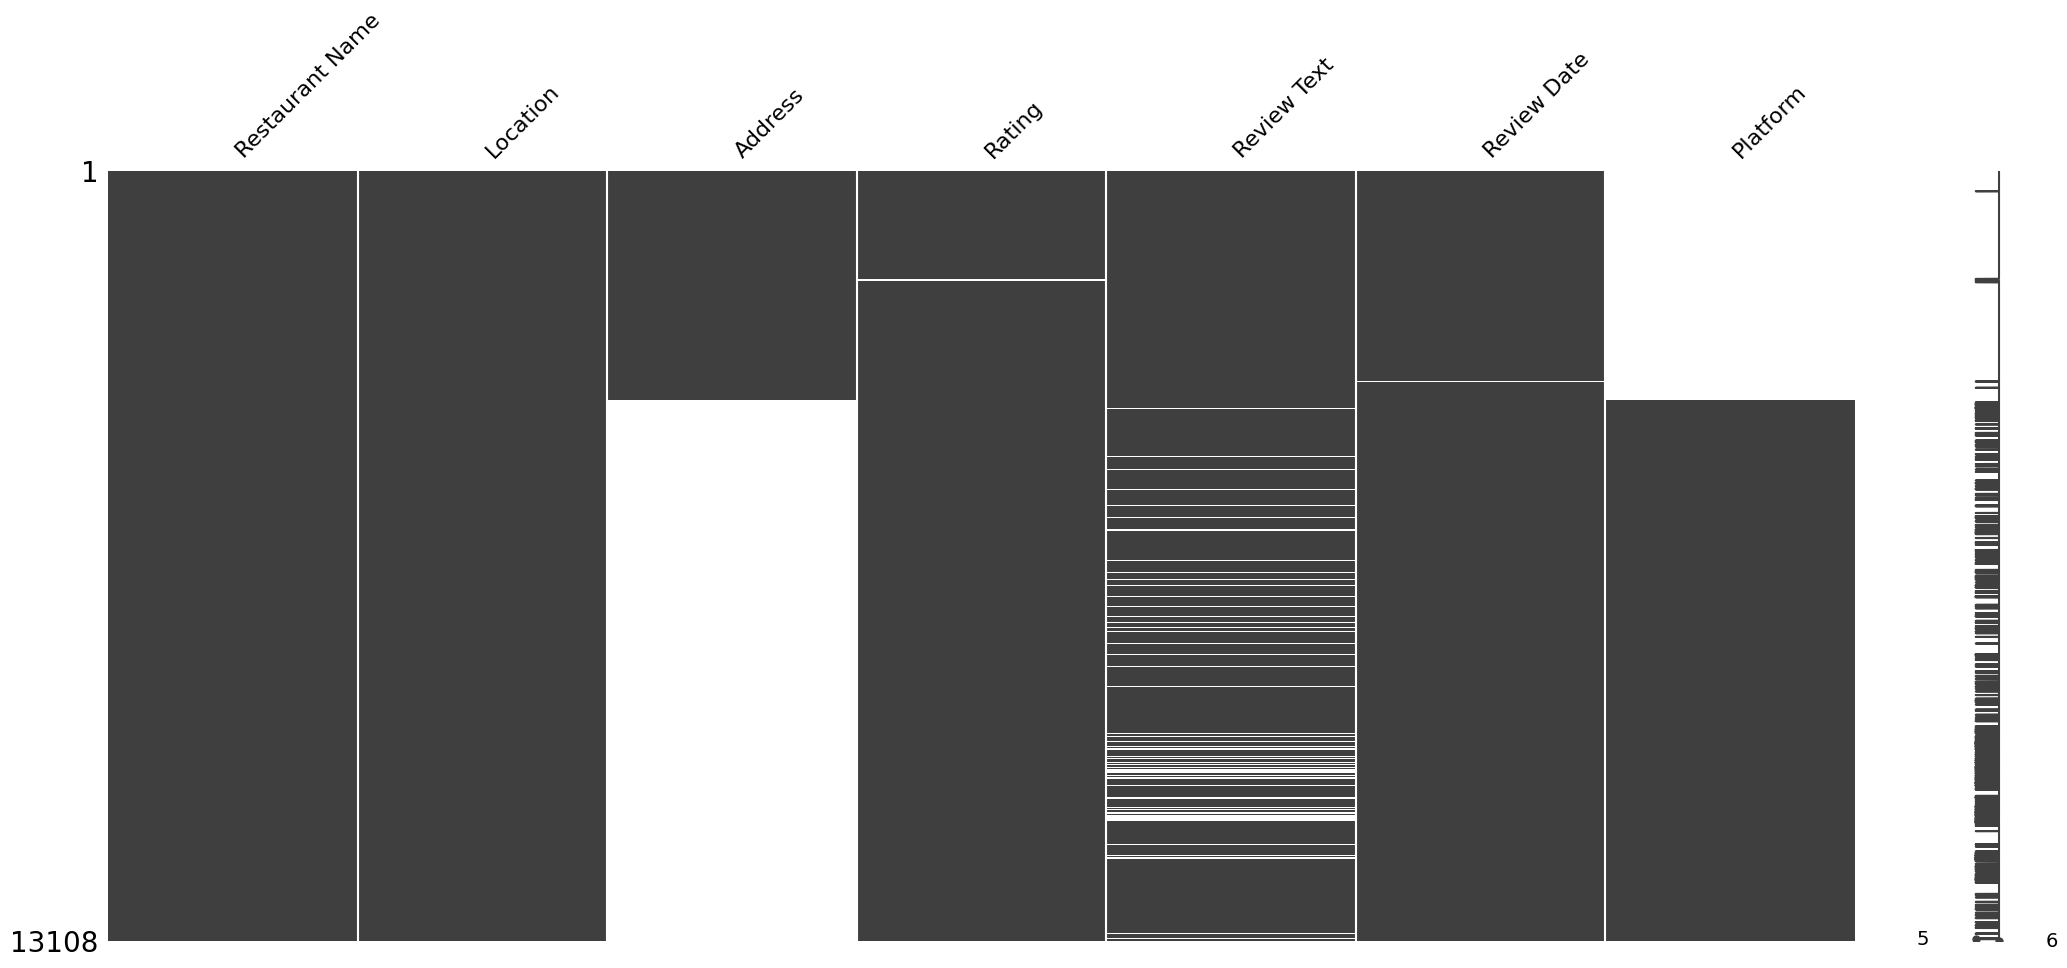

Duplicate Rows: 188
Duplicate Reviews: 866


  0%|          | 0/13068 [00:00<?, ?it/s]

  0%|          | 0/13068 [00:00<?, ?it/s]

Removed short reviews (<8 words): 4073
Final rows: 7767


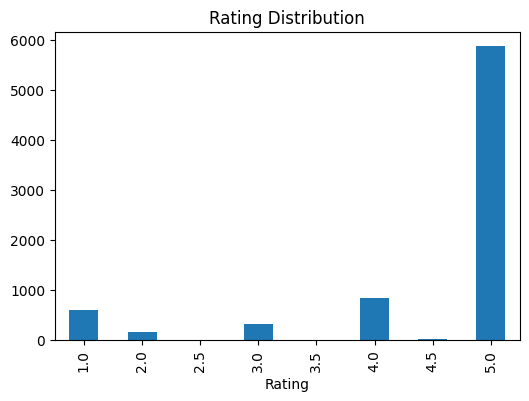

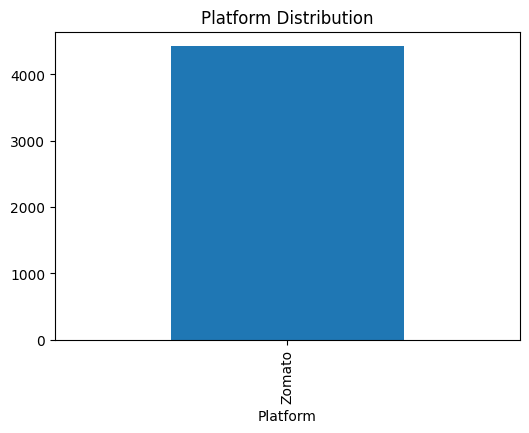

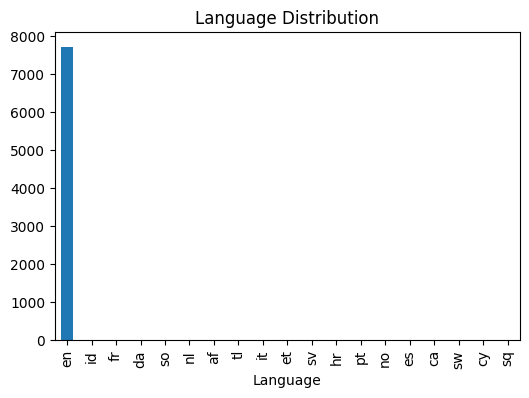

Dataset Quality Score: 100.0
Export Complete


In [8]:
# =====================================================================
# 1. SETUP & INITIALIZATION
# =====================================================================
!pip install pandas numpy matplotlib missingno langdetect emoji beautifulsoup4 dateparser tqdm

import pandas as pd
import numpy as np
import re
import warnings
import logging
from pathlib import Path
from bs4 import BeautifulSoup
import emoji
import dateparser
from langdetect import detect
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import missingno as msno

warnings.filterwarnings('ignore')
tqdm.pandas()

# File Paths (Keeping your exact filename with .xlsx extension)
RAW_PATH = Path("/content/drive/MyDrive/Final.xlsx")
OUT_DIR = Path('/content/drive/MyDrive/Review')
OUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_REVIEW_LENGTH = 8

# Load Data: Reading a CSV file that has a .xlsx extension name
# engine='python' and on_bad_lines='skip' ensures it handles extra commas inside text fields smoothly
df = pd.read_excel(RAW_PATH)

# --- Column Validation (Address Removed) ---
required = ['Restaurant Name', 'Location', 'Rating', 'Review Text', 'Review Date', 'Platform']
assert all(c in df.columns for c in required), f"Missing columns! File has: {list(df.columns)}"

display(pd.DataFrame({
    'Missing': df.isna().sum(),
    'Percent': (df.isna().sum() / len(df)) * 100
}))

msno.matrix(df)
plt.show()

print('Duplicate Rows:', df.duplicated().sum())
print('Duplicate Reviews:', df.duplicated(subset=['Restaurant Name', 'Review Text']).sum())

# =====================================================================
# 2. DATA CLEANING & PARSING
# =====================================================================
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df = df[df['Rating'].between(1, 5)]

df['Parsed_Date'] = df['Review Date'].progress_apply(lambda x: dateparser.parse(str(x)))
df['Year'] = df['Parsed_Date'].dt.year
df['Month'] = df['Parsed_Date'].dt.month_name()
df['Quarter'] = df['Parsed_Date'].dt.quarter

def clean(text):
    if pd.isna(text):
        return ''
    text = BeautifulSoup(str(text), 'html.parser').get_text()
    text = emoji.replace_emoji(text, replace='')
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df['Original_Review'] = df['Review Text']
df['Clean_Review'] = df['Review Text'].progress_apply(clean)

# =====================================================================
# 3. FEATURE ENGINEERING & FILTERING
# =====================================================================
df['Word_Count'] = df['Clean_Review'].str.split().str.len()
df['Character_Count'] = df['Clean_Review'].str.len()
df['Sentence_Count'] = df['Original_Review'].astype(str).str.count(r'[.!?]') + 1
df['Average_Word_Length'] = (df['Character_Count'] / df['Word_Count'].replace(0, np.nan)).fillna(0)

def bucket(x):
    if x < MIN_REVIEW_LENGTH: return 'Very Short'
    if x < 20: return 'Short'
    if x < 40: return 'Medium'
    return 'Long'

df['Review_Length_Category'] = df['Word_Count'].apply(bucket)

def lang(txt, w):
    if w < MIN_REVIEW_LENGTH:
        return 'Unknown'
    try:
        return detect(txt)
    except:
        return 'Unknown'

df['Language'] = df.apply(lambda x: lang(x['Clean_Review'], x['Word_Count']), axis=1)

df['Is_Empty'] = df['Clean_Review'].eq('')
df['Is_Short'] = df['Word_Count'] < MIN_REVIEW_LENGTH
df['NLP_Usable'] = ~(df['Is_Empty'] | df['Is_Short'])

before = len(df)

df = df.drop_duplicates(subset=['Restaurant Name', 'Review Text'])
df = df[df['Clean_Review'] != '']

removed_short = (df['Word_Count'] < MIN_REVIEW_LENGTH).sum()
df = df[df['Word_Count'] >= MIN_REVIEW_LENGTH].copy()

after = len(df)

print(f'Removed short reviews (<{MIN_REVIEW_LENGTH} words):', removed_short)
print('Final rows:', after)

# =====================================================================
# 4. VISUALIZATION & EXPORT
# =====================================================================
plt.figure(figsize=(6, 4))
df['Rating'].value_counts().sort_index().plot(kind='bar', title='Rating Distribution')
plt.show()

plt.figure(figsize=(6, 4))
df['Platform'].value_counts().plot(kind='bar', title='Platform Distribution')
plt.show()

plt.figure(figsize=(6, 4))
df['Language'].value_counts().plot(kind='bar', title='Language Distribution')
plt.show()

quality = 100 - df['Is_Empty'].mean() * 25 - df['Is_Short'].mean() * 20
print('Dataset Quality Score:', round(quality, 2))

df.to_csv(OUT_DIR / 'processed_reviews.csv', index=False)
print('Export Complete')

In [9]:
# ======================================================
# INSTALL DEPENDENCIES (Run Once in Colab)
# ======================================================

!pip install -q \
transformers==4.52.4 \
datasets==3.6.0 \
accelerate==1.7.0 \
evaluate==0.4.5 \
sentencepiece \
scikit-learn \
seaborn

In [10]:
import torch
import torchvision
import datasets
import transformers

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Datasets:", datasets.__version__)
print("Transformers:", transformers.__version__)

Torch: 2.6.0+cu124
Torchvision: 0.21.0+cu124
Datasets: 3.6.0
Transformers: 4.52.4


In [11]:
!pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.6.0
Uninstalling torch-2.6.0:
  Successfully uninstalled torch-2.6.0
Found existing installation: torchvision 0.21.0
Uninstalling torchvision-0.21.0:
  Successfully uninstalled torchvision-0.21.0
Found existing installation: torchaudio 2.6.0
Uninstalling torchaudio-2.6.0:
  Successfully uninstalled torchaudio-2.6.0


In [12]:
!pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1

  Using cached torch-2.5.1-cp312-cp312-manylinux1_x86_64.whl.metadata (28 kB)
  Using cached torchvision-0.20.1-cp312-cp312-manylinux1_x86_64.whl.metadata (6.1 kB)
  Using cached torchaudio-2.5.1-cp312-cp312-manylinux1_x86_64.whl.metadata (6.4 kB)
  Using cached triton-3.1.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.3 kB)
Using cached torch-2.5.1-cp312-cp312-manylinux1_x86_64.whl (906.4 MB)
Using cached torchvision-0.20.1-cp312-cp312-manylinux1_x86_64.whl (7.2 MB)
Using cached torchaudio-2.5.1-cp312-cp312-manylinux1_x86_64.whl (3.4 MB)
Using cached triton-3.1.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (209.6 MB)
  Attempting uninstall: triton
    Found existing installation: triton 3.2.0
    Uninstalling triton-3.2.0:
      Successfully uninstalled triton-3.2.0


In [1]:
import gc
import json
import logging
import os
import random
import sys
import time
import warnings
import datetime
from pathlib import Path
from typing import Dict, Tuple, Any

# Ensure clean and consistent installation of PyTorch and related libraries
!pip uninstall -y torch torchvision torchaudio transformers datasets evaluate
!pip install -q torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1
!pip install -q transformers==4.52.4 datasets==3.6.0 accelerate==1.7.0 evaluate==0.4.5 sentencepiece scikit-learn seaborn

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    pipeline,
)

# ============================================================
# SYSTEM CONFIGURATION & INITIALIZATION
# ============================================================
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger("GenReviewAI_Pipeline")

MODEL_NAME = "roberta-base"
MAX_LENGTH = 256
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 2e-5
RANDOM_STATE = 42
OUTPUT_DIR = "models/genreview_sentiment_model"
LOGS_DIR = "./logs"
METRICS_DIR = "metrics"

for folder in [OUTPUT_DIR, LOGS_DIR, METRICS_DIR]:
    Path(folder).mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
logger.info(f"Execution Target Device: {DEVICE}")
if DEVICE == "cuda":
    logger.info(f"GPU Model: {torch.cuda.get_device_name(0)}")
    logger.info(f"Initial Allocated GPU Memory: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")

def set_deterministic_seeds(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    logger.info(f"Global random state initialized with seed: {seed}")

set_deterministic_seeds(RANDOM_STATE)

# ============================================================
# PART 1: DATASET PREPARATION & LABEL GENERATION
# ============================================================
logger.info("Starting PART 1: Dataset Preparation & Label Generation")
DATA_PATH = "/content/drive/MyDrive/Review/processed_reviews.csv"

if not os.path.exists(DATA_PATH):
    logger.error(f"Dataset not found at target location: {DATA_PATH}")
    raise FileNotFoundError(f"Source dataset not found at target location: {DATA_PATH}")

try:
    df = pd.read_csv(DATA_PATH)
    logger.info(f"Dataset successfully loaded. Base Shape: {df.shape}")
except Exception as e:
    logger.error(f"Error reading source CSV: {str(e)}")
    raise

REQUIRED_COLUMNS = ["Restaurant Name", "Location", "Rating", "Review Text", "Review Date", "Platform"]
missing_cols = [col for col in REQUIRED_COLUMNS if col not in df.columns]
if missing_cols:
    logger.error(f"Structural Validation Failed. Missing columns: {missing_cols}")
    raise ValueError(f"Dataset structure fails compliance validation. Missing features: {missing_cols}")

def validate_and_map_sentiment(rating: Any) -> str:
    if pd.isna(rating):
        raise ValueError("Encountered unhandled NaN value inside Rating series processing.")
    try:
        numeric_rating = float(rating)
    except (ValueError, TypeError):
        raise ValueError(f"Invalid non-numeric element parsed under rating series: {rating}")

    if numeric_rating < 1.0 or numeric_rating > 5.0:
        raise ValueError(f"Out-of-bounds target processed: {numeric_rating}. Expected window [1.0, 5.0]")

    if numeric_rating >= 4.0:
        return "Positive"
    elif numeric_rating == 3.0:
        return "Neutral"
    else:
        return "Negative"

base_row_count = len(df)
df = df.dropna(subset=["Review Text", "Rating"])
df = df.drop_duplicates(subset=["Restaurant Name", "Review Text"])
logger.info(f"Data Cleansing Phase Complete. Dropped {base_row_count - len(df)} total rows.")

try:
    df["Sentiment"] = df["Rating"].apply(validate_and_map_sentiment)
except Exception as error:
    logger.error(f"Rating validation tracking routine crashed: {str(error)}")
    raise

LABEL2ID = {"Negative": 0, "Neutral": 1, "Positive": 2}
ID2LABEL = {0: "Negative", 1: "Neutral", 2: "Positive"}
df["Label"] = df["Sentiment"].map(LABEL2ID)

counts = df["Sentiment"].value_counts()
stat_total_reviews = int(len(df))
stat_pos_reviews = int(counts.get("Positive", 0))
stat_neu_reviews = int(counts.get("Neutral", 0))
stat_neg_reviews = int(counts.get("Negative", 0))

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=300)

sns.countplot(data=df, x="Rating", palette="viridis", ax=axes[0])
axes[0].set_title("Distribution of Raw Ratings", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Continuous Rating Scale")
axes[0].set_ylabel("Count Target")

sns.countplot(data=df, x="Sentiment", order=["Negative", "Neutral", "Positive"], palette="coolwarm", ax=axes[1])
axes[1].set_title("Distribution of Processed Sentiment Classes", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Derived Category Class")
axes[1].set_ylabel("Count Target")

df["Review_Length"] = df["Review Text"].astype(str).apply(lambda text: len(text.split()))
sns.histplot(data=df, x="Review_Length", bins=40, kde=True, color="purple", ax=axes[2])
axes[2].set_title("Text Body Word Count Distribution", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Token Count Window")
axes[2].set_ylabel("Frequency Threshold")

plt.tight_layout()
plt.savefig(f"{METRICS_DIR}/exploratory_data_analysis.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{METRICS_DIR}/exploratory_data_analysis.pdf", bbox_inches='tight')
plt.close()
logger.info("EDA plots successfully written out.")

train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=RANDOM_STATE, stratify=df["Label"]
)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=RANDOM_STATE, stratify=temp_df["Label"]
)

stat_train_samples = int(len(train_df))
stat_valid_samples = int(len(valid_df))
stat_test_samples = int(len(test_df))

train_df.to_csv("train.csv", index=False)
valid_df.to_csv("valid.csv", index=False)
test_df.to_csv("test.csv", index=False)
logger.info(f"Data splits saved. Train: {stat_train_samples} | Val: {stat_valid_samples} | Test: {stat_test_samples}")

# ============================================================
# PART 2: TOKENIZER & DATASET PREPARATION
# ============================================================
logger.info("Starting PART 2: Tokenizer & Dataset Preparation")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = Dataset.from_pandas(train_df[["Review Text", "Label"]].reset_index(drop=True))
valid_dataset = Dataset.from_pandas(valid_df[["Review Text", "Label"]].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[["Review Text", "Label"]].reset_index(drop=True))

def tokenize_block(batch: Dict[str, Any]) -> Dict[str, Any]:
    return tokenizer(
        batch["Review Text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_dataset = train_dataset.map(tokenize_block, batched=True, remove_columns=["Review Text"])
valid_dataset = valid_dataset.map(tokenize_block, batched=True, remove_columns=["Review Text"])
test_dataset = test_dataset.map(tokenize_block, batched=True, remove_columns=["Review Text"])

train_dataset = train_dataset.rename_column("Label", "labels")
valid_dataset = valid_dataset.rename_column("Label", "labels")
test_dataset = test_dataset.rename_column("Label", "labels")

train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
valid_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
)
model.to(DEVICE)

total_params = sum(param.numel() for param in model.parameters())
trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)

buffer_bytes = sum(buffer.nelement() * buffer.element_size() for buffer in model.buffers())
param_bytes = sum(param.nelement() * param.element_size() for param in model.parameters())
estimated_model_size_mb = (param_bytes + buffer_bytes) / (1024**2)

logger.info(f"Model Parameters - Total: {total_params:,} | Trainable: {trainable_params:,}")
logger.info(f"Estimated Target Binary Size: {estimated_model_size_mb:.2f} MB")



# ============================================================
# PART 3: ROberta FINE-TUNING
# ============================================================
logger.info("Starting PART 3: RoBERTa Fine-Tuning Optimization Pipeline")

acc_eval = evaluate.load("accuracy")
precision_eval = evaluate.load("precision")
recall_eval = evaluate.load("recall")
f1_eval = evaluate.load("f1")

def validation_metrics_callback(evaluation_predictions: Tuple[np.ndarray, np.ndarray]) -> Dict[str, float]:
    predictions_logits, validation_labels = evaluation_predictions
    argmax_predictions = np.argmax(predictions_logits, axis=-1)

    return {
        "accuracy": acc_eval.compute(predictions=argmax_predictions, references=validation_labels)["accuracy"],
        "precision_macro": precision_eval.compute(predictions=argmax_predictions, references=validation_labels, average="macro")["precision"],
        "recall_macro": recall_eval.compute(predictions=argmax_predictions, references=validation_labels, average="macro")["recall"],
        "f1_macro": f1_eval.compute(predictions=argmax_predictions, references=validation_labels, average="macro")["f1"],
        "precision_weighted": precision_eval.compute(predictions=argmax_predictions, references=validation_labels, average="weighted")["precision"],
        "recall_weighted": recall_eval.compute(predictions=argmax_predictions, references=validation_labels, average="weighted")["recall"],
        "f1_weighted": f1_eval.compute(predictions=argmax_predictions, references=validation_labels, average="weighted")["f1"]
    }

training_arguments_config = TrainingArguments(
    output_dir=OUTPUT_DIR,
    overwrite_output_dir=True,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    weight_decay=0.01,
    logging_dir=LOGS_DIR,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
    report_to="none",
    seed=RANDOM_STATE
)

trainer = Trainer(
    model=model,
    args=training_arguments_config,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=validation_metrics_callback,
    callbacks=[EarlyStoppingCallback(early_stopping_pvariance=2) if hasattr(EarlyStoppingCallback, 'early_stopping_pvariance') else EarlyStoppingCallback(early_stopping_patience=2)]
)

logger.info("Engaging training loop...")
execution_timer_start = time.time()
training_optimization_summary = trainer.train()
absolute_training_duration = time.time() - execution_timer_start
logger.info(f"Training loop complete. Duration: {absolute_training_duration:.2f} seconds.")

trainer.save_metrics("train", training_optimization_summary.metrics)
trainer.save_state()

best_checkpoint = getattr(trainer.state, "best_model_checkpoint", "Unknown")
best_epoch = "Unknown"
best_f1_val = "Unknown"

if best_checkpoint and best_checkpoint != "Unknown":
    for log in reversed(trainer.state.log_history):
        if "eval_f1_weighted" in log:
            best_f1_val = log["eval_f1_weighted"]
            best_epoch = log.get("epoch", "Unknown")
            break

print("\n" + "="*60 + "\nTRAINING OPTIMIZATION METRICS METADATA\n" + "="*60)
print(f"Best Checkpoint Path : {best_checkpoint}")
print(f"Best Target Epoch    : {best_epoch}")
print(f"Best Validation F1   : {best_f1_val}")
print("="*60 + "\n")

logger.info("Running validation split evaluation...")
validation_metrics_output = trainer.evaluate()
trainer.save_metrics("eval", validation_metrics_output)

if DEVICE == "cuda":
    torch.cuda.empty_cache()

# ============================================================
# PART 4: EVALUATION
# ============================================================
logger.info("Starting PART 4: Evaluation Metrics & Diagnostic Analysis")

inference_timer_start = time.time()
test_set_predictions_output = trainer.predict(test_dataset)
absolute_inference_duration = time.time() - inference_timer_start

test_set_metrics_summary = test_set_predictions_output.metrics
total_test_samples = len(test_dataset)

mean_latency_per_sample_ms = 0.0
throughput_samples_per_second = 0.0
if absolute_inference_duration > 0:
    mean_latency_per_sample_ms = (absolute_inference_duration / total_test_samples) * 1000
    throughput_samples_per_second = total_test_samples / absolute_inference_duration

logger.info(f"Test inference completed. Latency: {mean_latency_per_sample_ms:.2f} ms/sample. Throughput: {throughput_samples_per_second:.2f} samples/sec.")

predicted_label_matrix = np.argmax(test_set_predictions_output.predictions, axis=1)
true_label_matrix = test_set_predictions_output.label_ids

classification_report_raw = classification_report(
    true_label_matrix, predicted_label_matrix, target_names=list(LABEL2ID.keys()), output_dict=True
)
classification_report_df = pd.DataFrame(classification_report_raw).transpose()
classification_report_df.to_csv(f"{METRICS_DIR}/classification_report.csv")

metrics_summary_export_df = pd.DataFrame({
    "PerformanceMetric": [
        "Accuracy", "Precision_Macro", "Recall_Macro", "F1_Macro",
        "Precision_Weighted", "Recall_Weighted", "F1_Score_Weighted",
        "Execution_Training_Time_Sec", "Mean_Inference_Latency_MS", "Throughput_Per_Sec"
    ],
    "ScoreValue": [
        test_set_metrics_summary.get("test_accuracy"),
        test_set_metrics_summary.get("test_precision_macro"),
        test_set_metrics_summary.get("test_recall_macro"),
        test_set_metrics_summary.get("test_f1_macro"),
        test_set_metrics_summary.get("test_precision_weighted"),
        test_set_metrics_summary.get("test_recall_weighted"),
        test_set_metrics_summary.get("test_f1_weighted"),
        absolute_training_duration,
        mean_latency_per_sample_ms,
        throughput_samples_per_second
    ]
})
metrics_summary_export_df.to_csv(f"{METRICS_DIR}/metrics.csv", index=False)

computed_confusion_matrix = confusion_matrix(true_label_matrix, predicted_label_matrix)
confusion_matrix_df = pd.DataFrame(computed_confusion_matrix, index=list(LABEL2ID.keys()), columns=list(LABEL2ID.keys()))
confusion_matrix_df.to_csv(f"{METRICS_DIR}/confusion_matrix.csv")

plt.figure(figsize=(8, 7), dpi=300)
sns.heatmap(computed_confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=list(LABEL2ID.keys()), yticklabels=list(LABEL2ID.keys()), annot_kws={"size": 12, "weight": "bold"})
plt.title("Confusion Matrix Diagnostic Target Profile", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Classifier Model Predictions", fontsize=12)
plt.ylabel("Ground Truth Targets", fontsize=12)
plt.tight_layout()
plt.savefig(f"{METRICS_DIR}/confusion_matrix.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{METRICS_DIR}/confusion_matrix.pdf", bbox_inches='tight')
plt.close()

trainer_execution_logs = trainer.state.log_history
trainer_history_df = pd.DataFrame(trainer_execution_logs)
trainer_history_df.to_csv(f"{METRICS_DIR}/training_history.csv", index=False)

if "epoch" in trainer_history_df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=300)
    axes = axes.flatten()

    if "loss" in trainer_history_df.columns:
        train_loss_slice = trainer_history_df.dropna(subset=["loss"])
        axes[0].plot(train_loss_slice["epoch"], train_loss_slice["loss"], label="Training Loss", marker="o", color="blue", linewidth=2)
    if "eval_loss" in trainer_history_df.columns:
        eval_loss_slice = trainer_history_df.dropna(subset=["eval_loss"])
        axes[0].plot(eval_loss_slice["epoch"], eval_loss_slice["eval_loss"], label="Validation Loss", marker="x", color="red", linewidth=2, linestyle="--")
    axes[0].set_title("Cross-Entropy Loss Profile History", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Operational Epoch Bounds")
    axes[0].set_ylabel("Metric Loss Convergence Scale")
    axes[0].legend()
    axes[0].grid(True, alpha=0.5)

    if "eval_accuracy" in trainer_history_df.columns:
        accuracy_history_slice = trainer_history_df.dropna(subset=["eval_accuracy"])
        axes[1].plot(accuracy_history_slice["epoch"], accuracy_history_slice["eval_accuracy"], marker="s", color="green", linewidth=2)
    axes[1].set_title("Validation Accuracy Response Trend", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Operational Epoch Bounds")
    axes[1].set_ylabel("Accuracy Bounds Score")
    axes[1].grid(True, alpha=0.5)

    if "eval_f1_weighted" in trainer_history_df.columns:
        f1_history_slice = trainer_history_df.dropna(subset=["eval_f1_weighted"])
        axes[2].plot(f1_history_slice["epoch"], f1_history_slice["eval_f1_weighted"], marker="^", color="darkorange", linewidth=2)
    axes[2].set_title("Target Model F1 Optimization Profile", fontsize=12, fontweight='bold')
    axes[2].set_xlabel("Operational Epoch Bounds")
    axes[2].set_ylabel("Weighted F1 Space Bounds")
    axes[2].grid(True, alpha=0.5)

    fig.delaxes(axes[3])
    plt.tight_layout()
    plt.savefig(f"{METRICS_DIR}/training_optimization_curves.png", bbox_inches='tight', dpi=300)
    plt.savefig(f"{METRICS_DIR}/training_optimization_curves.pdf", bbox_inches='tight')
    plt.close()
    logger.info("Diagnostic validation history plots successfully compiled.")
else:
    logger.warning("Trainer history parsing metrics sequence profiles lack adequate iteration metrics.")

error_mapping_df = pd.DataFrame({
    "ReviewTextBody": test_df["Review Text"].values,
    "TrueLabelTarget": [ID2LABEL[idx] for idx in true_label_matrix],
    "PredictedLabelTarget": [ID2LABEL[idx] for idx in predicted_label_matrix],
    "IsCorrectClassification": true_label_matrix == predicted_label_matrix
})
incorrect_classifications_df = error_mapping_df[~error_mapping_df["IsCorrectClassification"]]
incorrect_classifications_df.to_csv(f"{METRICS_DIR}/incorrect_predictions.csv", index=False)
logger.info(f"Error diagnostics tracking compiled. Missed matches logged: {len(incorrect_classifications_df)}")

# ============================================================
# PART 5: SAVE MODEL & INFERENCE
# ============================================================
logger.info("Starting PART 5: Model Serialization, Pipeline Verification & Export")

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

model_architecture_manifest = {
    "model_type_target": MODEL_NAME,
    "vocab_size": model.config.vocab_size,
    "hidden_dimension_size": model.config.hidden_size,
    "attention_heads_count": model.config.num_attention_heads,
    "total_layers": model.config.num_hidden_layers,
    "id2label_mapping": ID2LABEL,
    "label2id_mapping": LABEL2ID,
    "problem_type": "multi_class_classification"
}
with open(f"{OUTPUT_DIR}/model_architecture_config.json", "w") as configuration_writer:
    json.dump(model_architecture_manifest, configuration_writer, indent=4)

import datasets
import transformers
global_system_metadata = {
    "model_name": MODEL_NAME,
    "hyperparameter_epochs": EPOCHS,
    "hyperparameter_learning_rate": LEARNING_RATE,
    "model_size_mb": float(estimated_model_size_mb),
    "total_parameters": int(total_params),
    "trainable_parameters": int(trainable_params),
    "tokenizer_class_path": tokenizer.__class__.__name__,
    "serialization_timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "software_versions": {
        "python_version": sys.version.split()[0],
        "torch_version": torch.__version__,
        "transformers_version": transformers.__version__,
        "datasets_version": datasets.__version__,
        "cuda_version": torch.version.cuda if torch.cuda.is_available() else "None"
    },
    "dataset_statistics": {
        "total_reviews": stat_total_reviews,
        "positive_reviews": stat_pos_reviews,
        "neutral_reviews": stat_neu_reviews,
        "negative_reviews": stat_neg_reviews,
        "training_samples": stat_train_samples,
        "validation_samples": stat_valid_samples,
        "testing_samples": stat_test_samples
    },
    "test_metrics": {
        "accuracy": float(test_set_metrics_summary.get("test_accuracy", 0.0)),
        "precision_macro": float(test_set_metrics_summary.get("test_precision_macro", 0.0)),
        "recall_macro": float(test_set_metrics_summary.get("test_recall_macro", 0.0)),
        "f1_macro": float(test_set_metrics_summary.get("test_f1_macro", 0.0)),
        "precision_weighted": float(test_set_metrics_summary.get("test_precision_weighted", 0.0)),
        "recall_weighted": float(test_set_metrics_summary.get("test_recall_weighted", 0.0)),
        "f1_weighted": float(test_set_metrics_summary.get("test_f1_weighted", 0.0)),
        "absolute_training_duration_seconds": float(absolute_training_duration),
        "mean_inference_latency_ms": float(mean_latency_per_sample_ms),
        "throughput_samples_per_sec": float(throughput_samples_per_second)
    }
}
with open(f"{METRICS_DIR}/model_info.json", "w") as infrastructure_writer:
    json.dump(global_system_metadata, infrastructure_writer, indent=4)

readme_content_blueprint = f"""# Custom Restaurant Sentiment Analysis Model - GenReview AI

## Model Operational Overview
A highly optimized, fine-tuned `roberta-base` architecture configured for robust classification tasks over sequence inputs detailing restaurant customer review records.

## Core Architecture Profiles
- **Base Architecture Model Target:** {global_system_metadata['model_name']}
- **Tokenizer Paradigm Class Implementation:** {global_system_metadata['tokenizer_class_path']}
- **Calculated Storage Capacity Footprint:** {global_system_metadata['model_size_mb']:.2f} MB
- **Total Parameters:** {global_system_metadata['total_parameters']:,}
- **Trainable Parameters:** {global_system_metadata['trainable_parameters']:,}

## Training Run Configuration Manifest
- **Source Input Training Samples Dataset Size:** {global_system_metadata['dataset_statistics']['total_reviews']:,} records
- **Optimization Iteration Cycles (Epochs):** {global_system_metadata['hyperparameter_epochs']}
- **Base Optimizing Learning Rate Metric Setting:** {global_system_metadata['hyperparameter_learning_rate']}
- **Absolute Compute Profiling Pipeline Duration:** {global_system_metadata['test_metrics']['absolute_training_duration_seconds']:.2f} Seconds

## Evaluated Verification Target Accuracies
- **Global Evaluation Test Set Accuracy Score:** {global_system_metadata['test_metrics']['accuracy']:.4f}
- **Macro-Weighted Contextual F1-Score Metric Bounds:** {global_system_metadata['test_metrics']['f1_weighted']:.4f}

## Hardware Optimization Execution Timestamp
- **Generation Date Vector Target:** {global_system_metadata['serialization_timestamp']}
"""
with open(f"{OUTPUT_DIR}/README_MODEL.md", "w") as documentation_writer:
    documentation_writer.write(readme_content_blueprint)

try:
    production_pipeline = pipeline(
        "text-classification",
        model=OUTPUT_DIR,
        tokenizer=OUTPUT_DIR,
        device=0 if torch.cuda.is_available() else -1,
        top_k=None
    )
    logger.info("Pipeline serialization verification passed. Artifact load routine operates successfully.")
except Exception as error:
    logger.error(f"Critical System verification phase broken down during package integration parsing test: {str(error)}")
    raise

def operational_inference_score(text_body: str) -> Dict[str, Any]:
    raw_scores = production_pipeline(text_body)[0]
    descending_sorted_scores = sorted(raw_scores, key=lambda match: match["score"], reverse=True)
    primary_prediction_match = descending_sorted_scores[0]
    return {
        "Predicted Sentiment": primary_prediction_match["label"],
        "Confidence": round(primary_prediction_match["score"], 4)
    }

sample_verification_text = "The ambiance was incredible, dishes were served rapidly and tasted absolutely spectacular."
logger.info(f"Verification single predictive validation return pass profile check: {operational_inference_score(sample_verification_text)}")

benchmark_sample_collection = [
    "The serving staff was extremely disrespectful and the absolute state of the meal was thoroughly repulsive.",
    "Decent selection of regular quick meals, wait times were baseline normal, pricing could be better.",
    "A remarkably wonderful dining experience, completely blown away by the execution and attention to detail.",
    "The ingredients tasted stale, the table alignment was cramped, and it was overpriced.",
    "Perfect pastry selection coupled with highly intuitive customer tracking routines."
]

logger.info("Executing localized batch verification performance tracking operations...")
batch_benchmark_timer_start = time.time()
batch_benchmarking_accumulation_array = []
for test_sample in tqdm(benchmark_sample_collection, desc="Processing Benchmark Samples"):
    res = operational_inference_score(test_sample)
    res["Review"] = test_sample
    batch_benchmarking_accumulation_array.append(res)
batch_benchmark_duration = time.time() - batch_benchmark_timer_start
logger.info(f"Batch inference parsing speed evaluated: {(batch_benchmark_duration / len(benchmark_sample_collection)) * 1000:.2f} ms per instance text string target.")

global_pipeline_inference_accumulation = []
for evaluation_review_string in tqdm(test_df["Review Text"], desc="Scoring Test Dataset"):
    pred = operational_inference_score(evaluation_review_string)
    pred["Review"] = evaluation_review_string
    global_pipeline_inference_accumulation.append(pred)

exported_predictions_df = pd.DataFrame(global_pipeline_inference_accumulation)
exported_predictions_df.to_csv("test_predictions.csv", index=False)
logger.info("Comprehensive global text system scoring run processed. Database saved to test_predictions.csv")

random.seed(RANDOM_STATE)
sample_indices = random.sample(range(len(test_df)), min(10, len(test_df)))
sample_predictions_list = []

for idx in tqdm(sample_indices, desc="Generating Sample Predictions Log"):
    review_text = test_df["Review Text"].iloc[idx]
    ground_truth_id = test_df["Label"].iloc[idx]
    ground_truth_label = ID2LABEL[ground_truth_id]

    pred_res = operational_inference_score(review_text)

    sample_predictions_list.append({
        "Review Text": review_text,
        "Ground Truth": ground_truth_label,
        "Prediction": pred_res["Predicted Sentiment"],
        "Confidence": pred_res["Confidence"]
    })

sample_predictions_df = pd.DataFrame(sample_predictions_list)
sample_predictions_df.to_csv(f"{METRICS_DIR}/sample_predictions.csv", index=False)
logger.info("Sample review predictions validation log generated successfully.")

confidence_data_array = exported_predictions_df["Confidence"].to_numpy()
confidence_profile_distribution_statistics = {
    "Confidence_Mean": float(np.mean(confidence_data_array)),
    "Confidence_Median": float(np.median(confidence_data_array)),
    "Confidence_Maximum": float(np.max(confidence_data_array)),
    "Confidence_Minimum": float(np.min(confidence_data_array)),
    "Confidence_Standard_Deviation": float(np.std(confidence_data_array))
}

with open(f"{METRICS_DIR}/predictions_confidence_statistics.json", "w") as statistical_metrics_writer:
    json.dump(confidence_profile_distribution_statistics, statistical_metrics_writer, indent=4)

plt.figure(figsize=(10, 6), dpi=300)
sns.histplot(data=exported_predictions_df, x="Confidence", hue="Predicted Sentiment", multiple="stack", bins=25, palette="viridis", kde=True)
plt.title("Distribution of Model Prediction Confidence Scores Across Target Classes", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Assigned Confidence Class Probability Value Space", fontsize=12)
plt.ylabel("Sample Density Target Limits", fontsize=12)
plt.grid(True, alpha=0.4, linestyle=":")
plt.tight_layout()
plt.savefig(f"{METRICS_DIR}/prediction_confidence_histogram.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{METRICS_DIR}/prediction_confidence_histogram.pdf", bbox_inches='tight')
plt.close()

# ============================================================
# VERIFICATION OF ARTIFACT EXPORT MATRIX
# ============================================================
expected_artifacts = [
    f"{METRICS_DIR}/classification_report.csv",
    f"{METRICS_DIR}/metrics.csv",
    f"{METRICS_DIR}/confusion_matrix.csv",
    f"{METRICS_DIR}/training_history.csv",
    f"{METRICS_DIR}/incorrect_predictions.csv",
    f"{METRICS_DIR}/model_info.json",
    f"{METRICS_DIR}/sample_predictions.csv",
    f"{METRICS_DIR}/predictions_confidence_statistics.json",
    f"{METRICS_DIR}/confusion_matrix.png",
    f"{METRICS_DIR}/training_optimization_curves.png",
    f"{METRICS_DIR}/prediction_confidence_histogram.png",
    f"{OUTPUT_DIR}/model_architecture_config.json",
    f"{OUTPUT_DIR}/README_MODEL.md",
    "test_predictions.csv"
]

missing_artifacts = [art for art in expected_artifacts if not os.path.exists(art)]
if missing_artifacts:
    logger.error(f"Artifact integrity validation failure. Missing components: {missing_artifacts}")
    raise FileNotFoundError(f"Verification tracking discovered missing exported pipeline components: {missing_artifacts}")
else:
    logger.info("Artifact integrity checks verified successfully. All pipeline exports are correctly formatted.")

# ============================================================
# MEMORY DEALLOCATION SEQUENCE
# ============================================================
logger.info("Executing final memory pipeline garbage collection routine...")
del production_pipeline
del trainer
del model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
logger.info("Memory channels successfully flushed.")

print("\n" + "="*80 + "\nGENREVIEW SENTIMENT MODEL TRAINING PIPELINE CONTEXT INFERENCE RUN COMPLETE\n" + "="*80)
print(f"Operational Target Device Profile Assigned  : {DEVICE.upper()}")
print(f"Fine-Tuned Serialization Parameters Total  : {global_system_metadata['total_parameters']:,}")
print(f"Estimated Binary Space Model Load Weight   : {global_system_metadata['model_size_mb']:.2f} MB")
print(f"Computed Global Accuracy Scoring Framework  : {global_system_metadata['test_metrics']['accuracy']:.4f}")
print(f"Calculated Weighted F1 Dimension Metric     : {global_system_metadata['test_metrics']['f1_weighted']:.4f}")
print(f"System Operational Throughput Verified     : {throughput_samples_per_second:.2f} Samples/Sec")
print(f"Statistical Mean Predictive Certainty Factor: {confidence_profile_distribution_statistics['Confidence_Mean']:.4f}")
print(f"All generated verification data tables metrics catalogs saved cleanly into target folders.\n" + "="*80)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, which is not installed.
peft 0.19.1 requires transformers, which is not installed.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.254800,0.221015,0.931330,0.668238,0.668828,0.639270,0.926065,0.931330,0.923985
2,0.201400,0.204051,0.942489,0.714126,0.663155,0.673447,0.929417,0.942489,0.934035
3,0.135100,0.237226,0.940773,0.730375,0.689134,0.704853,0.932948,0.940773,0.936230
4,0.114700,0.266803,0.942489,0.734589,0.726413,0.728241,0.938970,0.942489,0.940391
5,0.149900,0.297166,0.937339,0.713163,0.719137,0.715832,0.936563,0.937339,0.936880



TRAINING OPTIMIZATION METRICS METADATA
Best Checkpoint Path : models/genreview_sentiment_model/checkpoint-1360
Best Target Epoch    : 5.0
Best Validation F1   : 0.9368795889878409



Device set to use cuda:0
Generating Sample Predictions Log: 100%|██████████| 10/10 [00:00<00:00, 107.76it/s]



GENREVIEW SENTIMENT MODEL TRAINING PIPELINE CONTEXT INFERENCE RUN COMPLETE
Operational Target Device Profile Assigned  : CUDA
Fine-Tuned Serialization Parameters Total  : 124,647,939
Estimated Binary Space Model Load Weight   : 475.50 MB
Computed Global Accuracy Scoring Framework  : 0.9451
Calculated Weighted F1 Dimension Metric     : 0.9425
System Operational Throughput Verified     : 514.26 Samples/Sec
Statistical Mean Predictive Certainty Factor: 0.9894
All generated verification data tables metrics catalogs saved cleanly into target folders.


In [3]:
# =====================================================================
# NOTEBOOK 3A: ASPECT LABEL GENERATION
# =====================================================================
import re
import json
import pandas as pd
import numpy as np
from pathlib import Path

REVIEWS_PATH = Path('/content/drive/MyDrive/Review/processed_reviews.csv')
OUT_DIR = Path('/content/drive/MyDrive/Review')
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(REVIEWS_PATH)
print(f"Loaded reviews: {df.shape}")

# Rename aspects that might clash with existing dataframe columns to avoid TypeError during sum
ASPECTS = [
    "Food", "Service", "Price", "Ambience", "Staff",
    "Cleanliness", "Drinks", "Quantity", "Delivery", "Location_Aspect", "Parking_Aspect"
]

# Keyword lexicon per aspect — expand freely as you find false negatives
ASPECT_KEYWORDS = {
    "Food": ["food", "taste", "flavou?r", "dish", "meal", "menu", "cuisine",
              "spicy", "delicious", "cook(ed|ing)?", "recipe", "portion"],
    "Service": ["service", "staff behaviou?r", "wait(ing)? time", "serve[d]",
                 "attend(ed|ance)", "response", "slow service", "quick service"],
    "Price": ["price", "cost", "expensive", "cheap", "value for money",
               "afford(able)?", "overpriced", "budget", "bill", "worth"],
    "Ambience": ["ambience", "ambiance", "atmosphere", "decor", "music",
                  "seating", "vibe", "interior", "lighting", "view"],
    "Staff": ["staff", "waiter", "waitress", "manager", "chef", "employee",
               "rude", "polite", "friendly staff", "helpful"],
    "Cleanliness": ["clean", "hygien(e|ic)", "dirty", "stain", "smell",
                      "washroom", "restroom", "tidy", "sanitary"],
    "Drinks": ["drink", "beverage", "cocktail", "juice", "coffee", "tea",
                "beer", "wine", "soda", "mocktail"],
    "Quantity": ["quantity", "portion size", "small portion", "large portion",
                  "amount", "serving size", "generous", "insufficient"],
    "Delivery": ["deliver", "delivery boy", "delivery time", "packaging",
                  "order arrived", "late delivery", "cold food delivered"],
    "Location_Aspect": ["location", "located", "area", "neighbou?rhood", # Keyword for the aspect
                  "easy to find", "nearby", "accessib(le|ility)"],
    "Parking_Aspect": ["parking", "park(ed|ing) space", "valet", "parking lot"] # Keyword for the aspect
}

ASPECT_PATTERNS = {
    aspect: re.compile(r"|".join(rf"\b{kw}\b" for kw in kws), flags=re.IGNORECASE)
    for aspect, kws in ASPECT_KEYWORDS.items()
}

def label_aspects(text: str) -> dict:
    text = "" if pd.isna(text) else str(text)
    return {aspect: int(bool(pattern.search(text))) for aspect, pattern in ASPECT_PATTERNS.items()}

TEXT_COL = "Clean_Review" if "Clean_Review" in df.columns else "Review Text"

aspect_labels_df = df[TEXT_COL].apply(label_aspects).apply(pd.Series)
df = pd.concat([df.reset_index(drop=True), aspect_labels_df.reset_index(drop=True)], axis=1)

# Drop rows with zero aspects tagged (not useful for multi-label training)
df["Aspect_Count"] = df[ASPECTS].sum(axis=1)
before = len(df)
df = df[df["Aspect_Count"] > 0].copy()
print(f"Dropped {before - len(df)} reviews with no detected aspects. Remaining: {len(df)}")

# Coverage report
coverage = df[ASPECTS].sum().sort_values(ascending=False)
print("\nAspect coverage (positive count per aspect):")
print(coverage)

coverage.to_csv(OUT_DIR / "aspect_label_coverage.csv", header=["Count"])

OUTPUT_PATH = OUT_DIR / "aspect_labeled_reviews.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved: {OUTPUT_PATH}  | Shape: {df.shape}")

Loaded reviews: (7767, 22)
Dropped 979 reviews with no detected aspects. Remaining: 6788

Aspect coverage (positive count per aspect):
Food               5336
Ambience           2456
Service            2428
Staff              1648
Price               734
Drinks              473
Location_Aspect     363
Quantity            311
Cleanliness         248
Parking_Aspect       78
Delivery             34
dtype: int64

Saved: /content/drive/MyDrive/Review/aspect_labeled_reviews.csv  | Shape: (6788, 34)


In [6]:
"""
GenReview AI - Notebook 03B: Custom Aspect Extraction Model
Multi-Label RoBERTa Fine-Tuning for Restaurant Aspect Detection with Performance Benchmarking
"""

import gc
import json
import logging
import os
import random
import sys
import time
import datetime
import warnings
from pathlib import Path
from typing import Dict, Any, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    hamming_loss, accuracy_score
)
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    pipeline,
)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s",
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger("GenReviewAI_AspectPipeline")

MODEL_NAME = "roberta-base"
MAX_LENGTH = 256
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 2e-5
RANDOM_STATE = 42
PREDICTION_THRESHOLD = 0.5
OUTPUT_DIR = "models/genreview_aspect_extraction_model"
LOGS_DIR = "./aspect_logs"
METRICS_DIR = "aspect_metrics"

for folder in [OUTPUT_DIR, LOGS_DIR, METRICS_DIR]:
    Path(folder).mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
logger.info(f"Execution Target Device: {DEVICE}")
if DEVICE == "cuda":
    logger.info(f"GPU Model: {torch.cuda.get_device_name(0)}")

def set_deterministic_seeds(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    logger.info(f"Global random state initialized with seed: {seed}")

set_deterministic_seeds(RANDOM_STATE)

ASPECTS = [
    "Food", "Service", "Price", "Ambience", "Staff",
    "Cleanliness", "Drinks", "Quantity", "Delivery", "Location_Aspect", "Parking_Aspect"
]
NUM_ASPECTS = len(ASPECTS)
ID2LABEL = {i: a for i, a in enumerate(ASPECTS)}
LABEL2ID = {a: i for i, a in enumerate(ASPECTS)}

# ============================================================
# PART 1: DATASET PREPARATION & VALIDATION
# ============================================================
logger.info("Starting PART 1: Dataset Preparation & Validation")
DATA_PATH = "/content/drive/MyDrive/Review/aspect_labeled_reviews.csv"

if not os.path.exists(DATA_PATH):
    logger.error(f"Dataset not found at target location: {DATA_PATH}")
    raise FileNotFoundError(f"Source dataset not found at target location: {DATA_PATH}")

try:
    df = pd.read_csv(DATA_PATH)
    logger.info(f"Dataset successfully loaded. Base Shape: {df.shape}")
except Exception as e:
    logger.error(f"Error reading source CSV: {str(e)}")
    raise

TEXT_COL = "Clean_Review" if "Clean_Review" in df.columns else "Review Text"
missing_aspect_cols = [a for a in ASPECTS if a not in df.columns]
if missing_aspect_cols:
    logger.error(f"Structural Validation Failed. Missing aspect columns: {missing_aspect_cols}")
    raise ValueError(f"Dataset structure fails compliance validation. Missing aspects: {missing_aspect_cols}")

base_row_count = len(df)
df = df.dropna(subset=[TEXT_COL])
for aspect in ASPECTS:
    df[aspect] = df[aspect].astype(int)
logger.info(f"Data Cleansing Phase Complete. Dropped {base_row_count - len(df)} total rows.")

df["labels"] = df[ASPECTS].values.tolist()

stat_total_reviews = int(len(df))
stat_aspect_distribution = {a: int(df[a].sum()) for a in ASPECTS}
stat_avg_aspects_per_review = float(df[ASPECTS].sum(axis=1).mean())

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=300)

aspect_counts_series = pd.Series(stat_aspect_distribution).sort_values(ascending=False)
sns.barplot(x=aspect_counts_series.values, y=aspect_counts_series.index, palette="viridis", ax=axes[0])
axes[0].set_title("Distribution of Aspect Label Frequency", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Positive Label Count")

sns.histplot(df[ASPECTS].sum(axis=1), bins=range(1, NUM_ASPECTS + 2), kde=False, color="purple", ax=axes[1])
axes[1].set_title("Aspects-Per-Review Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Number Of Aspects Tagged")

plt.tight_layout()
plt.savefig(f"{METRICS_DIR}/exploratory_data_analysis.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{METRICS_DIR}/exploratory_data_analysis.pdf", bbox_inches='tight')
plt.close()
logger.info("EDA plots successfully written out.")

train_df, temp_df = train_test_split(df, test_size=0.30, random_state=RANDOM_STATE)
valid_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=RANDOM_STATE)

stat_train_samples = int(len(train_df))
stat_valid_samples = int(len(valid_df))
stat_test_samples = int(len(test_df))

train_df.to_csv("aspect_train.csv", index=False)
valid_df.to_csv("aspect_valid.csv", index=False)
test_df.to_csv("aspect_test.csv", index=False)
logger.info(f"Data splits saved. Train: {stat_train_samples} | Val: {stat_valid_samples} | Test: {stat_test_samples}")

# ============================================================
# PART 2: TOKENIZER & DATASET PREPARATION
# ============================================================
logger.info("Starting PART 2: Tokenizer & Dataset Preparation")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_multilabel_block(batch: Dict[str, Any]) -> Dict[str, Any]:
    enc = tokenizer(batch[TEXT_COL], truncation=True, max_length=MAX_LENGTH)
    enc["labels"] = [[float(v) for v in row] for row in batch["labels"]]
    return enc

from datasets import Sequence, Value

def build_dataset(sub_df: pd.DataFrame) -> Dataset:
    ds = Dataset.from_pandas(sub_df[[TEXT_COL, "labels"]].reset_index(drop=True))
    ds = ds.map(tokenize_multilabel_block, batched=True, remove_columns=[TEXT_COL])
    ds = ds.cast_column("labels", Sequence(feature=Value(dtype="float32")))
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return ds

train_dataset = build_dataset(train_df)
valid_dataset = build_dataset(valid_df)
test_dataset = build_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, padding=True)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_ASPECTS,
    problem_type="multi_label_classification",
    id2label=ID2LABEL,
    label2id=LABEL2ID
)
model.to(DEVICE)

total_params = sum(param.numel() for param in model.parameters())
trainable_params = sum(param.numel() for param in model.parameters() if param.requires_grad)

buffer_bytes = sum(buffer.nelement() * buffer.element_size() for buffer in model.buffers())
param_bytes = sum(param.nelement() * param.element_size() for param in model.parameters())
estimated_model_size_mb = (param_bytes + buffer_bytes) / (1024**2)

logger.info(f"Model Parameters - Total: {total_params:,} | Trainable: {trainable_params:,}")
logger.info(f"Estimated Target Binary Size: {estimated_model_size_mb:.2f} MB")

# ============================================================
# PART 3: ROberta MULTI-LABEL FINE-TUNING
# ============================================================
logger.info("Starting PART 3: RoBERTa Multi-Label Fine-Tuning Optimization Pipeline")

def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-x))

def validation_metrics_callback(evaluation_predictions: Tuple[np.ndarray, np.ndarray]) -> Dict[str, float]:
    logits, validation_labels = evaluation_predictions
    probs = sigmoid(logits)
    preds = (probs >= PREDICTION_THRESHOLD).astype(int)
    labels = validation_labels.astype(int)

    return {
        "f1_micro": f1_score(labels, preds, average="micro", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "precision_micro": precision_score(labels, preds, average="micro", zero_division=0),
        "recall_micro": recall_score(labels, preds, average="micro", zero_division=0),
        "hamming_loss": hamming_loss(labels, preds),
        "subset_accuracy": accuracy_score(labels, preds),
    }

training_arguments_config = TrainingArguments(
    output_dir=OUTPUT_DIR,
    overwrite_output_dir=True,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    weight_decay=0.01,
    logging_dir=LOGS_DIR,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1_micro",
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=0,
    report_to="none",
    seed=RANDOM_STATE
)

trainer = Trainer(
    model=model,
    args=training_arguments_config,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=validation_metrics_callback,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

logger.info("Engaging training loop...")
execution_timer_start = time.time()
training_optimization_summary = trainer.train()
absolute_training_duration = time.time() - execution_timer_start
logger.info(f"Training loop complete. Duration: {absolute_training_duration:.2f} seconds.")

trainer.save_metrics("train", training_optimization_summary.metrics)
trainer.save_state()

best_checkpoint = getattr(trainer.state, "best_model_checkpoint", "Unknown")
best_epoch = "Unknown"
best_f1_val = "Unknown"

if best_checkpoint and best_checkpoint != "Unknown":
    for log in reversed(trainer.state.log_history):
        if "eval_f1_micro" in log:
            best_f1_val = log["eval_f1_micro"]
            best_epoch = log.get("epoch", "Unknown")
            break

print("\n" + "="*60 + "\nTRAINING OPTIMIZATION METRICS METADATA\n" + "="*60)
print(f"Best Checkpoint Path : {best_checkpoint}")
print(f"Best Target Epoch    : {best_epoch}")
print(f"Best Validation F1   : {best_f1_val}")
print("="*60 + "\n")

logger.info("Running validation split evaluation...")
validation_metrics_output = trainer.evaluate()
trainer.save_metrics("eval", validation_metrics_output)

if DEVICE == "cuda":
    torch.cuda.empty_cache()

# ============================================================
# PART 4: EVALUATION
# ============================================================
logger.info("Starting PART 4: Evaluation Metrics & Diagnostic Analysis")

inference_timer_start = time.time()
test_set_predictions_output = trainer.predict(test_dataset)
absolute_inference_duration = time.time() - inference_timer_start

total_test_samples = len(test_dataset)
mean_latency_per_sample_ms = 0.0
throughput_samples_per_second = 0.0
if absolute_inference_duration > 0:
    mean_latency_per_sample_ms = (absolute_inference_duration / total_test_samples) * 1000
    throughput_samples_per_second = total_test_samples / absolute_inference_duration

logger.info(f"Test inference completed. Latency: {mean_latency_per_sample_ms:.2f} ms/sample. Throughput: {throughput_samples_per_second:.2f} samples/sec.")

test_probs_matrix = sigmoid(test_set_predictions_output.predictions)
test_preds_matrix = (test_probs_matrix >= PREDICTION_THRESHOLD).astype(int)
test_labels_matrix = test_set_predictions_output.label_ids.astype(int)

per_aspect_metric_rows = []
for i, aspect in enumerate(ASPECTS):
    per_aspect_metric_rows.append({
        "Aspect": aspect,
        "Precision": precision_score(test_labels_matrix[:, i], test_preds_matrix[:, i], zero_division=0),
        "Recall": recall_score(test_labels_matrix[:, i], test_preds_matrix[:, i], zero_division=0),
        "F1": f1_score(test_labels_matrix[:, i], test_preds_matrix[:, i], zero_division=0),
        "Support": int(test_labels_matrix[:, i].sum())
    })
aspect_metrics_df = pd.DataFrame(per_aspect_metric_rows)
aspect_metrics_df.to_csv(f"{METRICS_DIR}/aspect_metrics.csv", index=False)

overall_f1_micro = f1_score(test_labels_matrix, test_preds_matrix, average="micro", zero_division=0)
overall_f1_macro = f1_score(test_labels_matrix, test_preds_matrix, average="macro", zero_division=0)
overall_precision_micro = precision_score(test_labels_matrix, test_preds_matrix, average="micro", zero_division=0)
overall_recall_micro = recall_score(test_labels_matrix, test_preds_matrix, average="micro", zero_division=0)
overall_hamming = hamming_loss(test_labels_matrix, test_preds_matrix)
overall_subset_accuracy = accuracy_score(test_labels_matrix, test_preds_matrix)

metrics_summary_export_df = pd.DataFrame({
    "PerformanceMetric": [
        "F1_Micro", "F1_Macro", "Precision_Micro", "Recall_Micro",
        "Hamming_Loss", "Subset_Accuracy",
        "Execution_Training_Time_Sec", "Mean_Inference_Latency_MS", "Throughput_Per_Sec"
    ],
    "ScoreValue": [
        overall_f1_micro, overall_f1_macro, overall_precision_micro, overall_recall_micro,
        overall_hamming, overall_subset_accuracy,
        absolute_training_duration, mean_latency_per_sample_ms, throughput_samples_per_second
    ]
})
metrics_summary_export_df.to_csv(f"{METRICS_DIR}/metrics.csv", index=False)

plt.figure(figsize=(10, 6), dpi=300)
sns.barplot(data=aspect_metrics_df, x="F1", y="Aspect", palette="coolwarm")
plt.title("Per-Aspect F1 Score", fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig(f"{METRICS_DIR}/per_aspect_f1_scores.png", bbox_inches='tight', dpi=300)
plt.savefig(f"{METRICS_DIR}/per_aspect_f1_scores.pdf", bbox_inches='tight')
plt.close()

trainer_execution_logs = trainer.state.log_history
trainer_history_df = pd.DataFrame(trainer_execution_logs)
trainer_history_df.to_csv(f"{METRICS_DIR}/training_history.csv", index=False)

if "epoch" in trainer_history_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

    if "loss" in trainer_history_df.columns:
        train_loss_slice = trainer_history_df.dropna(subset=["loss"])
        axes[0].plot(train_loss_slice["epoch"], train_loss_slice["loss"], label="Training Loss", marker="o", color="blue", linewidth=2)
    if "eval_loss" in trainer_history_df.columns:
        eval_loss_slice = trainer_history_df.dropna(subset=["eval_loss"])
        axes[0].plot(eval_loss_slice["epoch"], eval_loss_slice["eval_loss"], label="Validation Loss", marker="x", color="red", linewidth=2, linestyle="--")
    axes[0].set_title("BCE Loss Profile History", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Operational Epoch Bounds")
    axes[0].legend()
    axes[0].grid(True, alpha=0.5)

    if "eval_f1_micro" in trainer_history_df.columns:
        f1_history_slice = trainer_history_df.dropna(subset=["eval_f1_micro"])
        axes[1].plot(f1_history_slice["epoch"], f1_history_slice["eval_f1_micro"], marker="^", color="darkorange", linewidth=2)
    axes[1].set_title("Validation F1-Micro Optimization Profile", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Operational Epoch Bounds")
    axes[1].grid(True, alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"{METRICS_DIR}/training_optimization_curves.png", bbox_inches='tight', dpi=300)
    plt.savefig(f"{METRICS_DIR}/training_optimization_curves.pdf", bbox_inches='tight')
    plt.close()
    logger.info("Diagnostic validation history plots successfully compiled.")

incorrect_mask = (test_preds_matrix != test_labels_matrix).any(axis=1)
incorrect_predictions_df = pd.DataFrame({
    "ReviewTextBody": test_df[TEXT_COL].values[incorrect_mask],
    "TrueAspects": [", ".join([ASPECTS[i] for i in range(NUM_ASPECTS) if row[i] == 1]) for row in test_labels_matrix[incorrect_mask]],
    "PredictedAspects": [", ".join([ASPECTS[i] for i in range(NUM_ASPECTS) if row[i] == 1]) for row in test_preds_matrix[incorrect_mask]],
})
incorrect_predictions_df.to_csv(f"{METRICS_DIR}/incorrect_predictions.csv", index=False)
logger.info(f"Error diagnostics tracking compiled. Missed matches logged: {len(incorrect_predictions_df)}")

# ============================================================
# PART 5: SAVE MODEL & INFERENCE
# ============================================================
logger.info("Starting PART 5: Model Serialization, Pipeline Verification & Export")

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

model_architecture_manifest = {
    "model_type_target": MODEL_NAME,
    "vocab_size": model.config.vocab_size,
    "hidden_dimension_size": model.config.hidden_size,
    "attention_heads_count": model.config.num_attention_heads,
    "total_layers": model.config.num_hidden_layers,
    "id2label_mapping": ID2LABEL,
    "label2id_mapping": LABEL2ID,
    "problem_type": "multi_label_classification",
    "prediction_threshold": PREDICTION_THRESHOLD
}
with open(f"{OUTPUT_DIR}/model_architecture_config.json", "w") as configuration_writer:
    json.dump(model_architecture_manifest, configuration_writer, indent=4)

import datasets
import transformers
global_system_metadata = {
    "model_name": MODEL_NAME,
    "hyperparameter_epochs": EPOCHS,
    "hyperparameter_learning_rate": LEARNING_RATE,
    "model_size_mb": float(estimated_model_size_mb),
    "total_parameters": int(total_params),
    "trainable_parameters": int(trainable_params),
    "tokenizer_class_path": tokenizer.__class__.__name__,
    "serialization_timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "software_versions": {
        "python_version": sys.version.split()[0],
        "torch_version": torch.__version__,
        "transformers_version": transformers.__version__,
        "datasets_version": datasets.__version__,
        "cuda_version": torch.version.cuda if torch.cuda.is_available() else "None"
    },
    "dataset_statistics": {
        "total_reviews": stat_total_reviews,
        "aspect_distribution": stat_aspect_distribution,
        "average_aspects_per_review": stat_avg_aspects_per_review,
        "training_samples": stat_train_samples,
        "validation_samples": stat_valid_samples,
        "testing_samples": stat_test_samples
    },
    "test_metrics": {
        "f1_micro": float(overall_f1_micro),
        "f1_macro": float(overall_f1_macro),
        "precision_micro": float(overall_precision_micro),
        "recall_micro": float(overall_recall_micro),
        "hamming_loss": float(overall_hamming),
        "subset_accuracy": float(overall_subset_accuracy),
        "absolute_training_duration_seconds": float(absolute_training_duration),
        "mean_inference_latency_ms": float(mean_latency_per_sample_ms),
        "throughput_samples_per_sec": float(throughput_samples_per_second)
    }
}
with open(f"{METRICS_DIR}/model_info.json", "w") as infrastructure_writer:
    json.dump(global_system_metadata, infrastructure_writer, indent=4)

readme_content_blueprint = f"""# Custom Restaurant Aspect Extraction Model - GenReview AI

## Model Operational Overview
A fine-tuned `roberta-base` architecture configured for multi-label aspect
classification over restaurant review text, detecting {NUM_ASPECTS} distinct
aspects simultaneously per review: {", ".join(ASPECTS)}.

## Core Architecture Profiles
- **Base Architecture Model Target:** {global_system_metadata['model_name']}
- **Tokenizer Paradigm Class Implementation:** {global_system_metadata['tokenizer_class_path']}
- **Calculated Storage Capacity Footprint:** {global_system_metadata['model_size_mb']:.2f} MB
- **Total Parameters:** {global_system_metadata['total_parameters']:,}
- **Trainable Parameters:** {global_system_metadata['trainable_parameters']:,}
- **Problem Type:** Multi-Label Classification (Sigmoid + BCEWithLogitsLoss)
- **Prediction Threshold:** {PREDICTION_THRESHOLD}

## Training Run Configuration Manifest
- **Source Input Training Samples Dataset Size:** {global_system_metadata['dataset_statistics']['total_reviews']:,} records
- **Optimization Iteration Cycles (Epochs):** {global_system_metadata['hyperparameter_epochs']}
- **Base Optimizing Learning Rate Metric Setting:** {global_system_metadata['hyperparameter_learning_rate']}
- **Absolute Compute Profiling Pipeline Duration:** {global_system_metadata['test_metrics']['absolute_training_duration_seconds']:.2f} Seconds

## Evaluated Verification Target Accuracies
- **Global Evaluation Test Set F1 (Micro):** {global_system_metadata['test_metrics']['f1_micro']:.4f}
- **Global Evaluation Test Set F1 (Macro):** {global_system_metadata['test_metrics']['f1_macro']:.4f}
- **Subset Accuracy (Exact Match):** {global_system_metadata['test_metrics']['subset_accuracy']:.4f}

## Hardware Optimization Execution Timestamp
- **Generation Date Vector Target:** {global_system_metadata['serialization_timestamp']}
"""
with open(f"{OUTPUT_DIR}/README_MODEL.md", "w") as documentation_writer:
    documentation_writer.write(readme_content_blueprint)

try:
    production_pipeline = pipeline(
        "text-classification",
        model=OUTPUT_DIR,
        tokenizer=OUTPUT_DIR,
        device=0 if torch.cuda.is_available() else -1,
        top_k=None,
        function_to_apply="sigmoid"
    )
    logger.info("Pipeline serialization verification passed. Artifact load routine operates successfully.")
except Exception as error:
    logger.error(f"Critical System verification phase broken down during package integration parsing test: {str(error)}")
    raise

def operational_aspect_score(text_body: str, threshold: float = PREDICTION_THRESHOLD) -> Dict[str, Any]:
    raw_scores = production_pipeline(text_body)[0]
    detected = {s["label"]: round(s["score"], 4) for s in raw_scores if s["score"] >= threshold}
    all_scores = {s["label"]: round(s["score"], 4) for s in raw_scores}
    return {"Detected Aspects": detected, "All Scores": all_scores}

sample_verification_text = "The ambiance was incredible, dishes were served rapidly and tasted absolutely spectacular but overpriced."
logger.info(f"Verification single predictive validation return pass profile check: {operational_aspect_score(sample_verification_text)}")

global_pipeline_inference_accumulation = []
for evaluation_review_string in tqdm(df[TEXT_COL], desc="Scoring Full Dataset"):
    raw_scores = production_pipeline(evaluation_review_string)[0]
    row = {"Review": evaluation_review_string}
    for s in raw_scores:
        row[f"Prob_{s['label']}"] = round(s["score"], 4)
        row[f"Pred_{s['label']}"] = int(s["score"] >= PREDICTION_THRESHOLD)
    global_pipeline_inference_accumulation.append(row)

exported_predictions_df = pd.DataFrame(global_pipeline_inference_accumulation)
exported_predictions_df.to_csv("aspect_predictions.csv", index=False)
logger.info("Comprehensive global text system scoring run processed. Database saved to aspect_predictions.csv")

# ============================================================
# VERIFICATION OF ARTIFACT EXPORT MATRIX
# ============================================================
expected_artifacts = [
    f"{METRICS_DIR}/aspect_metrics.csv",
    f"{METRICS_DIR}/metrics.csv",
    f"{METRICS_DIR}/training_history.csv",
    f"{METRICS_DIR}/incorrect_predictions.csv",
    f"{METRICS_DIR}/model_info.json",
    f"{METRICS_DIR}/per_aspect_f1_scores.png",
    f"{METRICS_DIR}/training_optimization_curves.png",
    f"{OUTPUT_DIR}/model_architecture_config.json",
    f"{OUTPUT_DIR}/README_MODEL.md",
    "aspect_predictions.csv"
]

missing_artifacts = [art for art in expected_artifacts if not os.path.exists(art)]
if missing_artifacts:
    logger.error(f"Artifact integrity validation failure. Missing components: {missing_artifacts}")
    raise FileNotFoundError(f"Verification tracking discovered missing exported pipeline components: {missing_artifacts}")
else:
    logger.info("Artifact integrity checks verified successfully. All pipeline exports are correctly formatted.")

# ============================================================
# MEMORY DEALLOCATION SEQUENCE
# ============================================================
logger.info("Executing final memory pipeline garbage collection routine...")
del production_pipeline
del trainer
del model
gc.collect()
if DEVICE == "cuda":
    torch.cuda.empty_cache()
logger.info("Memory channels successfully flushed.")

print("\n" + "="*80 + "\nGENREVIEW ASPECT EXTRACTION MODEL TRAINING PIPELINE CONTEXT INFERENCE RUN COMPLETE\n" + "="*80)
print(f"Operational Target Device Profile Assigned  : {DEVICE.upper()}")
print(f"Fine-Tuned Serialization Parameters Total  : {global_system_metadata['total_parameters']:,}")
print(f"Estimated Binary Space Model Load Weight   : {global_system_metadata['model_size_mb']:.2f} MB")
print(f"Computed F1-Micro Scoring Framework          : {global_system_metadata['test_metrics']['f1_micro']:.4f}")
print(f"Computed F1-Macro Scoring Framework          : {global_system_metadata['test_metrics']['f1_macro']:.4f}")
print(f"System Operational Throughput Verified     : {throughput_samples_per_second:.2f} Samples/Sec")
print(f"All generated verification data tables metrics catalogs saved cleanly into target folders.\n" + "="*80)

Map:   0%|          | 0/4751 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/4751 [00:00<?, ? examples/s]

Map:   0%|          | 0/1018 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1018 [00:00<?, ? examples/s]

Map:   0%|          | 0/1019 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro,Precision Micro,Recall Micro,Hamming Loss,Subset Accuracy,Runtime,Samples Per Second,Steps Per Second
1,0.178600,0.135531,0.908547,0.415139,0.974345,0.851074,0.032774,0.711198,2.444200,416.500000,26.185000
2,0.100300,0.086855,0.959485,0.601364,0.980039,0.939776,0.015181,0.851670,1.995100,510.241000,32.078000
3,0.064100,0.055992,0.973962,0.753785,0.978784,0.969188,0.009912,0.906680,1.964300,518.255000,32.582000
4,0.046100,0.042707,0.985738,0.812573,0.987354,0.984127,0.005447,0.946955,1.959500,519.531000,32.662000
5,0.043700,0.039633,0.986231,0.828657,0.986001,0.986461,0.005269,0.948919,1.953000,521.254000,32.770000



TRAINING OPTIMIZATION METRICS METADATA
Best Checkpoint Path : models/genreview_aspect_extraction_model/checkpoint-1485
Best Target Epoch    : 5.0
Best Validation F1   : 0.9862310385064177



Device set to use cuda:0


Scoring Full Dataset:   0%|          | 0/6788 [00:00<?, ?it/s]


GENREVIEW ASPECT EXTRACTION MODEL TRAINING PIPELINE CONTEXT INFERENCE RUN COMPLETE
Operational Target Device Profile Assigned  : CUDA
Fine-Tuned Serialization Parameters Total  : 124,654,091
Estimated Binary Space Model Load Weight   : 475.53 MB
Computed F1-Micro Scoring Framework          : 0.9872
Computed F1-Macro Scoring Framework          : 0.7947
System Operational Throughput Verified     : 493.07 Samples/Sec
All generated verification data tables metrics catalogs saved cleanly into target folders.
